# Setup & Data Loading

## Environment Configuration

In [20]:
import sys
import time
import warnings
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import center_of_mass, shift
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, train_test_split, learning_curve, cross_val_score
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, pairwise_distances, classification_report, log_loss, confusion_matrix, f1_score
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import fetch_openml
from tqdm.notebook import tqdm
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.exceptions import ConvergenceWarning #---

np.random.seed(42)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning, module='sklearn')

# Environment Configuration (Local vs Colab)

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    base_dir = '/content/drive/MyDrive/MNIST_Project'
else:
    base_dir = '.'

figures_dir = os.path.join(base_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

print(f"Setup Completed! Figures will be saved at: {figures_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup Completed! Figures will be saved at: /content/drive/MyDrive/MNIST_Project/figures


## Loading the Mnist Dataset

In [21]:
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X, y = mnist["data"], mnist["target"].astype(int)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Fetching MNIST dataset...
Train: (60000, 784), Test: (10000, 784)


# Exploratory Data Analysis

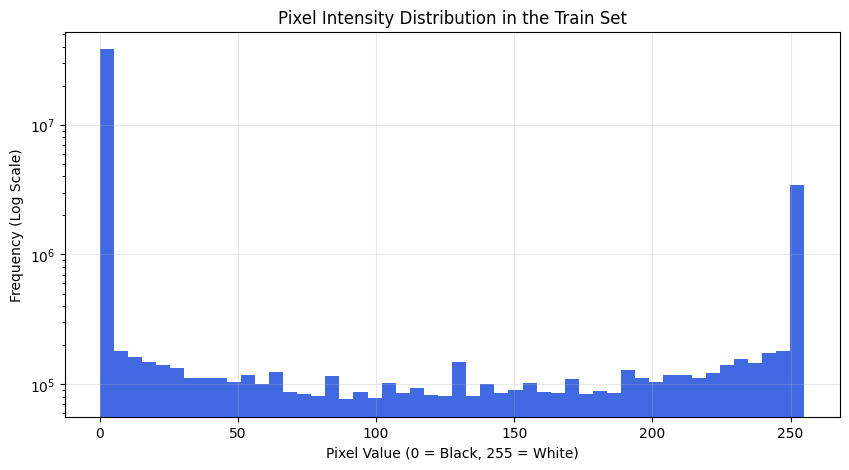

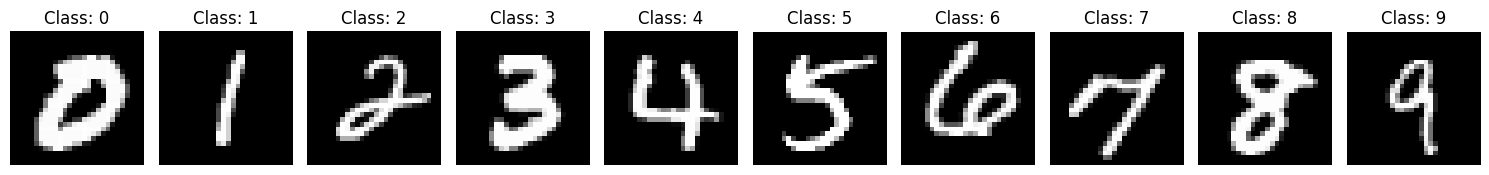

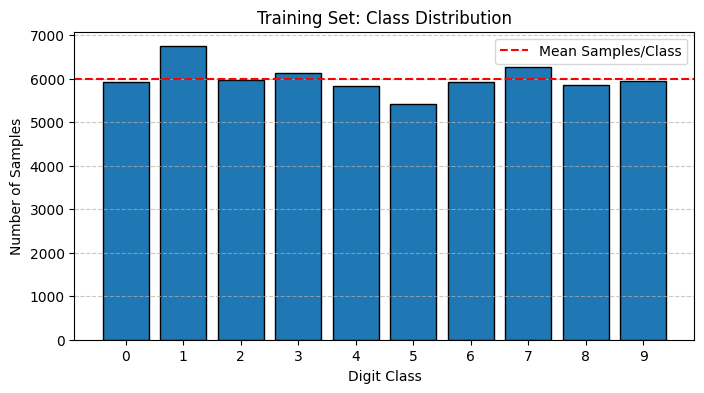

In [22]:
# Generate pixel intensity distribution (Histogram)
plt.figure(figsize=(10, 5))
plt.hist(X_train.flatten(), bins=50, color='royalblue', log=True)
plt.title('Pixel Intensity Distribution in the Train Set')
plt.xlabel('Pixel Value (0 = Black, 255 = White)')
plt.ylabel('Frequency (Log Scale)')
plt.grid(True, alpha=0.3)
plt.savefig(f"{figures_dir}/pixel_intensity_distribution.pdf", format='pdf', bbox_inches='tight')
plt.show()
print("\n")

# Generate random samples from each class
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    # Extract indices where the label equals the current class
    class_indices = np.where(y_train == i)[0]
    # Select a random sample
    random_idx = np.random.choice(class_indices)
    img = X_train[random_idx].reshape(28, 28)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Class: {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"{figures_dir}/random_samples.pdf", format='pdf', bbox_inches='tight')
plt.show()
print("\n")

# Class Distribution
class_counts = np.bincount(y_train)
classes = np.arange(len(class_counts))

plt.figure(figsize=(8, 4))
plt.bar(classes, class_counts, edgecolor='black')
plt.axhline(y=np.mean(class_counts), color='r', linestyle='--', label='Mean Samples/Class')
plt.xticks(classes)
plt.xlabel("Digit Class")
plt.ylabel("Number of Samples")
plt.title("Training Set: Class Distribution")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(f"{figures_dir}/class_distribution.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Data Preprocessing & Subsampling

## Type Casting (float32)

In [23]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

## Data Normalization

In [24]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Subsampling for Scenario A

In [25]:
def get_balanced_subset_indices(y, samples_per_class=1000):
    indices = []
    for cls in np.unique(y):
        cls_indices = np.where(y == cls)[0]
        selected = np.random.choice(cls_indices, samples_per_class, replace=False)
        indices.extend(selected)

    indices = np.array(indices)
    np.random.shuffle(indices)
    return indices

subset_indices = get_balanced_subset_indices(y_train, samples_per_class=1000)

X_full_A = X_train[subset_indices]
y_full_A = y_train[subset_indices]

print(f"Scenario A Data prepared:: {X_full_A.shape} | {y_full_A.shape}")

Scenario A Data prepared:: (10000, 784) | (10000,)


# Feature Engineering (Theoritical Overview)

## Spatial Transformation (Image Centering)

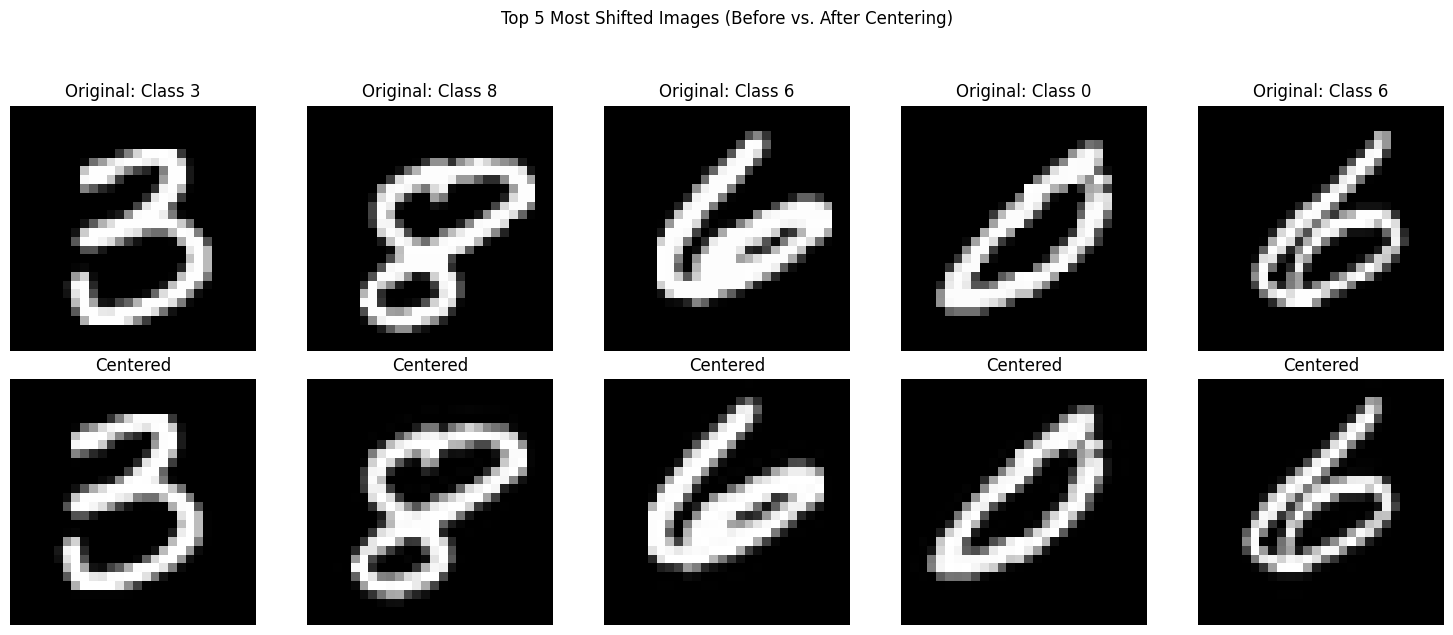

In [28]:
def center_images(X_data):
    """
    Calculates the center of mass for each image and shifts it so that
    the center of mass aligns with the geometric center (13.5, 13.5).
    Expects normalized data [0, 1].
    """
    N = X_data.shape[0]
    X_centered = np.zeros_like(X_data)

    for i in range(N):
        img = X_data[i].reshape(28, 28)

        # Add 1e-5 to avoid ZeroDivisionError on completely black images
        cy, cx = center_of_mass(img + 1e-5)

        # Calculate shift and apply it
        centered_img = shift(img, shift=(13.5 - cy, 13.5 - cx), mode='constant', cval=0.0)

        X_centered[i] = np.clip(centered_img, 0.0, 1.0).flatten()

    return X_centered

X_train_centered = center_images(X_full_A)
# X_test_centered = center_images(X_test)

# Identify the top 5 images that underwent the most extreme shifts
pixel_differences = np.sum(np.abs(X_full_A - X_train_centered), axis=1)
top_5_changed_indices = np.argsort(pixel_differences)[-5:]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Top 5 Most Shifted Images (Before vs. After Centering)', y=1.05)

for i, idx in enumerate(top_5_changed_indices):
    # Top row: Original images from the subset
    axes[0, i].imshow(X_full_A[idx].reshape(28, 28), cmap='gray', vmin=0.0, vmax=1.0)
    axes[0, i].set_title(f"Original: Class {y_full_A[idx]}")
    axes[0, i].axis('off')

    # Bottom row: Centered images
    axes[1, i].imshow(X_train_centered[idx].reshape(28, 28), cmap='gray', vmin=0.0, vmax=1.0)
    axes[1, i].set_title("Centered")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f"{figures_dir}/image_centering_comparison.pdf", bbox_inches='tight')
plt.show()

## Dimensionality Reduction (PCA)

### Varience Analysis

In [ ]:
pca_full = PCA()
pca_full.fit(X_full_A)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

d_optimal = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2.5)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance Threshold')
plt.axvline(x=d_optimal, color='g', linestyle='--', label=f'Selected Components (d={d_optimal})')
plt.title('PCA on MNIST Training Set: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(f"{figures_dir}/pca_cumulative_variance.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Custom Implementations: Linear Classifiers

## Experimental Setup

In [ ]:
X_train_poc, X_test_poc, y_train_poc, y_test_poc = train_test_split(
    X_full_A, y_full_A, test_size=0.2, stratify=y_full_A, random_state=42
)

print("=== Scenario A: Data prepared for Custom Models POC ===")
print(f"Training subset:   {X_train_poc.shape} | {y_train_poc.shape}")
print(f"Testing subset:    {X_test_poc.shape} | {y_test_poc.shape}")

## Implementations

In [ ]:
class BinaryPerceptron:
    def __init__(self, learning_rate=0.01, max_epochs=1000):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = 0
        self.n_iter_ = 0
        self.loss_history = []
        self.val_loss_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.n_iter_ = 0
        self.loss_history = []
        self.val_loss_history = []

        for epoch in range(self.max_epochs):
            self.n_iter_ += 1
            errors = 0

            # Shuffle training data for Stochastic Gradient Descent
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Training Update (Sample by Sample)
            for idx, x_i in enumerate(X_shuffled):
                linear_output = np.dot(x_i, self.weights) + self.bias
                if y_shuffled[idx] * linear_output <= 0:
                    update = self.lr * y_shuffled[idx]
                    self.weights += update * x_i
                    self.bias += update
                    errors += 1

            # Loss Calculation (Perceptron Criterion)
            # Computed on the static (unshuffled) X for consistent loss tracking
            train_dist = y * (np.dot(X, self.weights) + self.bias)
            train_loss = np.mean(np.maximum(0, -train_dist))
            self.loss_history.append(train_loss)

            # Validation Loss Calculation
            if X_val is not None and y_val is not None:
                val_dist = y_val * (np.dot(X_val, self.weights) + self.bias)
                val_loss = np.mean(np.maximum(0, -val_dist))
                self.val_loss_history.append(val_loss)

            if errors == 0:
                break # Perfect linear separation achieved

    def decision_function(self, X):
        return np.dot(X, self.weights) + self.bias

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)


class CustomPerceptronOvA:
    def __init__(self, learning_rate=0.01, max_epochs=1000):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.models = {}
        self.classes_ = None
        self.total_steps_ = 0
        self.max_steps_ = 0

    def fit(self, X, y, X_val=None, y_val=None):
        self.classes_ = np.unique(y)
        steps_per_model = []

        # Train a binary classifier for each class against the rest
        for c in self.classes_:
            y_binary = np.where(y == c, 1, -1)

            y_val_binary = None
            if y_val is not None:
                y_val_binary = np.where(y_val == c, 1, -1)

            model = BinaryPerceptron(learning_rate=self.lr, max_epochs=self.max_epochs)
            model.fit(X, y_binary, X_val, y_val_binary)

            self.models[c] = model
            steps_per_model.append(model.n_iter_)

        self.total_steps_ = sum(steps_per_model)
        self.max_steps_ = max(steps_per_model)

    def predict(self, X):
        scores = np.zeros((X.shape[0], len(self.classes_)))
        # Collect decision function margins from all models
        for idx, c in enumerate(self.classes_):
            scores[:, idx] = self.models[c].decision_function(X)
        # Select the class with the highest margin
        return self.classes_[np.argmax(scores, axis=1)]


class CustomPerceptronOvO:
    def __init__(self, learning_rate=0.01, max_epochs=1000):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.models = {}
        self.classes_ = None
        self.total_steps_ = 0
        self.max_steps_ = 0

    def fit(self, X, y, X_val=None, y_val=None):
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        steps_per_model = []

        # Train a binary classifier for every unique pair of classes
        for i in range(n_classes):
            for j in range(i + 1, n_classes):
                c1, c2 = self.classes_[i], self.classes_[j]

                # Filter Training Set for the two specific classes
                mask = (y == c1) | (y == c2)
                X_pair = X[mask]
                y_pair_raw = y[mask]
                y_binary = np.where(y_pair_raw == c1, 1, -1)

                # Filter Validation Set for the two specific classes
                X_val_pair = None
                y_val_binary = None
                if X_val is not None and y_val is not None:
                    mask_val = (y_val == c1) | (y_val == c2)
                    X_val_pair = X_val[mask_val]
                    y_val_pair_raw = y_val[mask_val]
                    y_val_binary = np.where(y_val_pair_raw == c1, 1, -1)

                model = BinaryPerceptron(learning_rate=self.lr, max_epochs=self.max_epochs)
                model.fit(X_pair, y_binary, X_val_pair, y_val_binary)

                self.models[(c1, c2)] = model
                steps_per_model.append(model.n_iter_)

        self.total_steps_ = sum(steps_per_model)
        self.max_steps_ = max(steps_per_model)

    def predict(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        votes = np.zeros((n_samples, n_classes))
        class_to_idx = {c: i for i, c in enumerate(self.classes_)}

        # Tally votes from all binary classifiers
        for (c1, c2), model in self.models.items():
            predictions = model.predict(X)
            idx_c1 = class_to_idx[c1]
            idx_c2 = class_to_idx[c2]
            votes[predictions == 1, idx_c1] += 1
            votes[predictions == -1, idx_c2] += 1

        # Predict the class with the majority vote
        return self.classes_[np.argmax(votes, axis=1)]

class CustomSoftmax:
    def __init__(self, learning_rate=0.1, max_epochs=2000, tol=1e-6, lambda_reg=0.01, patience=5):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.tol = tol
        self.lambda_reg = lambda_reg
        self.patience = patience # Consecutive epochs allowed with increasing validation loss
        self.weights = None
        self.bias = None
        self.n_iter_ = 0
        self.loss_history = []
        self.val_loss_history = []
        self.classes_ = None

    def _softmax(self, z):
        # Numerical stability: subtract max before exponentiating
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros(n_classes)
        self.n_iter_ = 0
        self.loss_history = []
        self.val_loss_history = []

        # Early stopping tracking variables
        val_increases = 0
        best_val_loss = float('inf')

        # One-hot encode training labels
        Y_one_hot = np.zeros((n_samples, n_classes))
        for i, c in enumerate(self.classes_):
            Y_one_hot[:, i] = (y == c).astype(int)

        # One-hot encode validation labels
        if X_val is not None and y_val is not None:
            n_val_samples = X_val.shape[0]
            Y_val_one_hot = np.zeros((n_val_samples, n_classes))
            for i, c in enumerate(self.classes_):
                Y_val_one_hot[:, i] = (y_val == c).astype(int)

        for epoch in range(self.max_epochs):
            self.n_iter_ += 1

            # --- Training Forward Pass ---
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._softmax(linear_model)

            # Cross-Entropy Loss with L2 Regularization
            data_loss = -np.mean(np.sum(Y_one_hot * np.log(y_predicted + 1e-15), axis=1))
            reg_loss = (self.lambda_reg / 2) * np.sum(self.weights ** 2)
            total_loss = data_loss + reg_loss
            self.loss_history.append(total_loss)

            # --- Validation Forward Pass & Strict Early Stopping ---
            if X_val is not None and y_val is not None:
                val_linear = np.dot(X_val, self.weights) + self.bias
                val_predicted = self._softmax(val_linear)
                val_data_loss = -np.mean(np.sum(Y_val_one_hot * np.log(val_predicted + 1e-15), axis=1))
                val_total_loss = val_data_loss + reg_loss
                self.val_loss_history.append(val_total_loss)

                # Check if validation loss has degraded
                if val_total_loss > best_val_loss:
                    val_increases += 1
                else:
                    best_val_loss = val_total_loss
                    val_increases = 0 # Reset counter on new minimum

                # Terminate if patience is exhausted
                if val_increases >= self.patience:
                    print(f"Early stopping triggered at epoch {epoch} to prevent overfitting.")
                    break
            else:
                # Fallback to tolerance-based stopping ONLY if no validation set is provided
                if epoch > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tol:
                    break

            # --- Backward Pass (Gradient Computation) ---
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - Y_one_hot)) + self.lambda_reg * self.weights
            db = (1 / n_samples) * np.sum(y_predicted - Y_one_hot, axis=0)

            # Weight Updates
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        probabilities = self._softmax(linear_model)
        return self.classes_[np.argmax(probabilities, axis=1)]

## Excecution & Visualization

In [ ]:
# Helper function to calculate model memory footprint (in KB)
def get_model_memory(model_obj):
    total_bytes = 0
    # For Softmax, which directly contains weights/bias arrays
    if hasattr(model_obj, 'weights') and model_obj.weights is not None:
        total_bytes += model_obj.weights.nbytes
        total_bytes += model_obj.bias.nbytes if hasattr(model_obj.bias, 'nbytes') else 8

    # For OvA/OvO, which contain dictionaries of BinaryPerceptron objects
    if hasattr(model_obj, 'models'):
        for m in model_obj.models.values():
            if m.weights is not None:
                total_bytes += m.weights.nbytes
                total_bytes += m.bias.nbytes if hasattr(m.bias, 'nbytes') else 8

    return total_bytes / 1024  # Convert bytes to KB

# 1. SOFTMAX
start_time = time.time()
softmax = CustomSoftmax(learning_rate=1, max_epochs=2000, tol=1e-6, lambda_reg=0.0001)
softmax.fit(X_train_poc, y_train_poc, X_val=X_test_poc, y_val=y_test_poc)
time_softmax = time.time() - start_time
mem_softmax = get_model_memory(softmax)
pred_softmax = softmax.predict(X_test_poc)
acc_softmax = accuracy_score(y_test_poc, pred_softmax)

# 2. PERCEPTRON OvA
start_time = time.time()
ova = CustomPerceptronOvA(learning_rate=0.01, max_epochs=1000)
ova.fit(X_train_poc, y_train_poc, X_val=X_test_poc, y_val=y_test_poc)
time_ova = time.time() - start_time
mem_ova = get_model_memory(ova)
pred_ova = ova.predict(X_test_poc)
acc_ova = accuracy_score(y_test_poc, pred_ova)

# 3. PERCEPTRON OvO
start_time = time.time()
ovo = CustomPerceptronOvO(learning_rate=0.01, max_epochs=1000)
ovo.fit(X_train_poc, y_train_poc, X_val=X_test_poc, y_val=y_test_poc)
time_ovo = time.time() - start_time
mem_ovo = get_model_memory(ovo)
pred_ovo = ovo.predict(X_test_poc)
acc_ovo = accuracy_score(y_test_poc, pred_ovo)

# DataFrame Formatting
results_data = {
    "Model": ["Softmax", "Perceptron OvA", "Perceptron OvO"],
    "Accuracy (%)": [acc_softmax * 100, acc_ova * 100, acc_ovo * 100],
    "Convergence (Steps)": [softmax.n_iter_, ova.total_steps_, ovo.total_steps_],
    "Model Memory (KB)": [mem_softmax, mem_ova, mem_ovo],
    "Training Time (sec)": [time_softmax, time_ova, time_ovo]
}

df_results = pd.DataFrame(results_data)

df_formatted = df_results.copy()
df_formatted["Accuracy (%)"] = df_formatted["Accuracy (%)"].map("{:.2f}".format)
df_formatted["Model Memory (KB)"] = df_formatted["Model Memory (KB)"].map("{:.2f}".format)
df_formatted["Training Time (sec)"] = df_formatted["Training Time (sec)"].map("{:.2f}".format)

print(df_formatted.to_string(index=False))

latex_path = os.path.join(figures_dir, 'custom_models_results.tex')
df_formatted.to_latex(latex_path, index=False, column_format='lcccc', caption='Proof of Concept Results for Custom Linear Models', label='tab:poc_custom_models')

# 4. VISUALIZATIONS

# Graph 1: Softmax Loss
plt.figure(figsize=(8, 6))
plt.plot(softmax.loss_history, color='blue', label='Training Loss')
if hasattr(softmax, 'val_loss_history') and len(softmax.val_loss_history) > 0:
    plt.plot(softmax.val_loss_history, color='orange', linestyle='--', label='Validation Loss')
plt.title('Softmax Convergence (Cross-Entropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
softmax_path = os.path.join(figures_dir, 'softmax_loss_curve.pdf')
plt.savefig(softmax_path, dpi=300)
plt.show()
plt.close()

# Graph 2: OvO Task Difficulty
plt.figure(figsize=(8, 6))
loss_01 = ovo.models[(0, 1)].loss_history
loss_49 = ovo.models[(4, 9)].loss_history

plt.plot(loss_01, color='green', linewidth=2, label='0 vs 1 (Easy Separability)')
plt.plot(loss_49, color='red', linewidth=2, alpha=0.8, label='4 vs 9 (Hard Separability)')

plt.title('OvO: Task Difficulty Comparison')
plt.xlabel('Epochs')
plt.ylabel('Perceptron Criterion Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
ovo_diff_path = os.path.join(figures_dir, 'ovo_task_difficulty.pdf')
plt.savefig(ovo_diff_path, dpi=300)
plt.show()
plt.close()

# Transition to Scikit-Learn

# Experimental Setup

## Feature Space Optimization

In [ ]:
# --- 1. PRE-COMPUTING INDEPENDENT FEATURE SPACES ---
X_train_centered_A = center_images(X_full_A)

# Dictionary defining the base data and whether PCA should be applied in the pipeline
scenario_A_dict = {
    "1_Raw": {"data": X_full_A, "use_pca": False},
    "2_PCA": {"data": X_full_A, "use_pca": True},
    "3_Centered": {"data": X_train_centered_A, "use_pca": False},
    "4_Centered_PCA": {"data": X_train_centered_A, "use_pca": True}
}

# --- 2. EVALUATION HELPER & MODELS ---
def get_sklearn_memory(estimator):
    """Calculates the weight size in KB for sklearn models."""
    total_bytes = 0

    # Extract the classifier if it's wrapped inside a Pipeline
    if hasattr(estimator, 'named_steps'):
        clf = estimator.named_steps['clf']
    else:
        clf = estimator

    # For simple models (SGDClassifier)
    if hasattr(clf, 'coef_'):
        total_bytes += clf.coef_.nbytes + clf.intercept_.nbytes
    # For Ensembles (OvA, OvO)
    elif hasattr(clf, 'estimators_'):
        for model in clf.estimators_:
            total_bytes += model.coef_.nbytes + model.intercept_.nbytes

    return total_bytes / 1024.0

# Standardized Baseline Models
baseline_models = {
    "Softmax (SGD)": SGDClassifier(loss='log_loss', max_iter=1000, random_state=42),
    "Perceptron OvA": OneVsRestClassifier(Perceptron(max_iter=1000, random_state=42)),
    "Perceptron OvO": OneVsOneClassifier(Perceptron(max_iter=1000, random_state=42))
}

# --- 3. PHASE 0 EXECUTION ---
phase0_results = []
print("Starting Phase 0...\n")

for data_name, config in scenario_A_dict.items():
    X_data = config["data"]
    use_pca = config["use_pca"]

    for model_name, base_model in baseline_models.items():

        # Dynamically integrate PCA during CV
        if use_pca:
            model = Pipeline([('pca', PCA(n_components=0.95, random_state=42)), ('clf', base_model)])
        else:
            model = base_model

        # Calculate Accuracy with 5-Fold CV
        cv_scores = cross_val_score(model, X_data, y_full_A, cv=5, scoring='accuracy', n_jobs=-1)
        mean_cv_acc = cv_scores.mean()

        # Calculate Time & Memory with a single fit
        start_t = time.time()
        model.fit(X_data, y_full_A)
        train_time = time.time() - start_t

        mem_kb = get_sklearn_memory(model)

        phase0_results.append({
            "Feature_Space": data_name,
            "Model": model_name,
            "CV_Accuracy": f"{mean_cv_acc * 100:.2f}%",
            "Train_Time_sec": f"{train_time:.2f}",
            "Memory_KB": f"{mem_kb:.2f}",
            "_raw_score": mean_cv_acc # Hidden field for sorting
        })

results_df = pd.DataFrame(phase0_results)
results_df = results_df.sort_values(by=["Model", "_raw_score"], ascending=[True, False]).drop(columns=['_raw_score']).reset_index(drop=True)

pd.set_option('display.max_colwidth', None)
print(results_df.to_string())

csv_path = os.path.join(figures_dir, 'feature_representation_study.csv')
tex_path = os.path.join(figures_dir, 'feature_representation_study.tex')

results_df.to_csv(csv_path, index=False)
results_df.to_latex(tex_path, index=False)

## Validation Strategy

#  Scenario A: Standard Classification

## Hyperparameter Tuning

In [ ]:
print("Starting Scenario A: Hyperparameter Tuning (GridSearch)...\n")

X_opt_train = center_images(X_full_A)
y_opt_train = y_full_A

# --- SEARCH SPACE CONFIGURATION ---
# NOTE: Estimators are wrapped in Pipelines to dynamically apply PCA during CV.
models_config = {
    "Softmax (SGD)": {
        "estimator": Pipeline([
            ('pca', PCA(n_components=0.95, random_state=42)),
            ('clf', SGDClassifier(loss='log_loss', random_state=42))
        ]),
        "params": [
            # 1. Constant LR + L2 Regularization
            {
                'clf__learning_rate': ['constant'],
                'clf__eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
                'clf__penalty': ['l2'],
                'clf__alpha': [0.000001, 0.00001, 0.0001, 0.001],
                'clf__max_iter': [10, 50, 200]
            },
            # 2. Optimal LR + L2 Regularization (eta0 is ignored)
            {
                'clf__learning_rate': ['optimal'],
                'clf__penalty': ['l2'],
                'clf__alpha': [0.000001, 0.00001, 0.0001, 0.001],
                'clf__max_iter': [10, 50, 200]
            },
            # 3. Constant LR + No Regularization (alpha is omitted)
            {
                'clf__learning_rate': ['constant'],
                'clf__eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
                'clf__penalty': [None],
                'clf__max_iter': [10, 50, 200]
            }
        ]
    },
    "Perceptron OvA": {
        "estimator": Pipeline([
            ('pca', PCA(n_components=0.95, random_state=42)),
            ('clf', OneVsRestClassifier(Perceptron(random_state=42)))
        ]),
        "params": [
            # 1. L2 Regularization
            {
                'clf__estimator__penalty': ['l2'],
                'clf__estimator__alpha': [0.000001, 0.00001, 0.0001, 0.001],
                'clf__estimator__eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
                'clf__estimator__max_iter': [10, 50, 200]
            },
            # 2. No Regularization (alpha is omitted)
            {
                'clf__estimator__penalty': [None],
                'clf__estimator__eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
                'clf__estimator__max_iter': [10, 50, 200]
            }
        ]
    },
    "Perceptron OvO": {
        "estimator": Pipeline([
            ('pca', PCA(n_components=0.95, random_state=42)),
            ('clf', OneVsOneClassifier(Perceptron(random_state=42)))
        ]),
        "params": [
            # 1. L2 Regularization
            {
                'clf__estimator__penalty': ['l2'],
                'clf__estimator__alpha': [0.000001, 0.00001, 0.0001, 0.001],
                'clf__estimator__eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
                'clf__estimator__max_iter': [10, 50, 200]
            },
            # 2. No Regularization
            {
                'clf__estimator__penalty': [None],
                'clf__estimator__eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
                'clf__estimator__max_iter': [10, 50, 200]
            }
        ]
    }
}

# --- EXECUTE GRID SEARCH ---
grid_results = []
best_estimators_dict = {} # Dictionary for Phase 2

for model_name, config in models_config.items():

    grid = GridSearchCV(
        estimator=config['estimator'],
        param_grid=config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    start_t = time.time()
    grid.fit(X_opt_train, y_opt_train)
    train_time = time.time() - start_t

    # Save the best pipeline (PCA + Classifier)
    best_pipeline = grid.best_estimator_
    best_estimators_dict[model_name] = best_pipeline

    # Extract the classifier from the pipeline to access its internal attributes
    clf_model = best_pipeline.named_steps['clf']

    # Extract Epochs
    if hasattr(clf_model, 'estimators_'):
        iters = [m.n_iter_ for m in clf_model.estimators_]
        avg_epochs = np.mean(iters)
        max_epochs = np.max(iters)
    else:
        avg_epochs = clf_model.n_iter_
        max_epochs = clf_model.n_iter_

    # Clean parameter names for a cleaner print output
    clean_params = {k.replace('clf__estimator__', '').replace('clf__', ''): v for k, v in grid.best_params_.items()}

    grid_results.append({
        "Model": model_name,
        "CV_Accuracy": f"{grid.best_score_ * 100:.2f}%",
        "Best_Params": str(clean_params),
        "Avg_Epochs": f"{avg_epochs:.1f}",
        "Max_Epochs": max_epochs,
        "Train_Time_sec": f"{train_time:.2f}",
        "_raw_score": grid.best_score_
    })

# --- FINAL DISPLAY & EXPORT ---
df_grid = pd.DataFrame(grid_results)
df_grid = df_grid.sort_values(by="_raw_score", ascending=False).drop(columns=['_raw_score']).reset_index(drop=True)

pd.set_option('display.max_colwidth', None)
print("--- SCENARIO A: FINAL GRID SEARCH RESULTS ---")
print(df_grid.to_string())

os.makedirs(figures_dir, exist_ok=True)
csv_path = os.path.join(figures_dir, 'scenario_A_gridsearch_final.csv')
tex_path = os.path.join(figures_dir, 'scenario_A_gridsearch_final.tex')

df_grid.to_csv(csv_path, index=False)
df_grid.to_latex(tex_path, index=False)

## Grid Search Results & Analysis

## Model Evaluation & Error Diagnostics

In [19]:
print("Starting Phase 2: Complete Evaluation Pipeline...\n")

classes = np.unique(y_opt_train)

# PART 2A: OPTIMIZATION DYNAMICS (TRAINING SET ONLY)
print("--> Executing Part 2A: Optimization Dynamics (Training Set Only)")

# Extract the trained PCA from the best Softmax model (fitted on training data during GridSearch)
trained_pca = best_estimators_dict["Softmax (SGD)"].named_steps['pca']

# Manually transform the data for partial_fit compatibility
X_opt_train_pca = trained_pca.transform(X_opt_train)

epochs = 25
softmax_scenarios = {
    "Optimal (Constant 0.01)": SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.01, penalty='l2', alpha=1e-05, random_state=42),
    "Schedule (Optimal)": SGDClassifier(loss='log_loss', learning_rate='optimal', penalty='l2', alpha=1e-05, random_state=42),
    "Too Small (Constant 1e-6)": SGDClassifier(loss='log_loss', learning_rate='constant', eta0=1e-06, penalty='l2', alpha=1e-05, random_state=42),
    "Too Large (Constant 1.0)": SGDClassifier(loss='log_loss', learning_rate='constant', eta0=1.0, penalty='l2', alpha=1e-05, random_state=42),
    "Schedule (Optimal + alpha=1e-03)": SGDClassifier(loss='log_loss', learning_rate='optimal', penalty='l2', alpha=1e-03, random_state=42)
}

plt.figure(figsize=(10, 6))
for name, clf in softmax_scenarios.items():
    loss_history = []
    epochs_survived = 0

    for epoch in range(epochs):
        clf.partial_fit(X_opt_train_pca, y_opt_train, classes=classes)
        try:
            proba = clf.predict_proba(X_opt_train_pca)

            # If weights have exploded, probabilities will contain NaN.
            if np.isnan(proba).any() or np.isinf(proba).any():
                raise ValueError("Numerical Explosion")

            loss_history.append(log_loss(y_opt_train, proba))
            epochs_survived += 1

        except ValueError:
            print(f" [Info] Model '{name}' diverged (Exploding Gradients) at Epoch {epoch + 1}.")
            break # Stop "feeding" the broken model

    # Plot the curve only for the epochs it survived before crashing
    if epochs_survived > 0:
        plt.plot(range(1, epochs_survived + 1), loss_history, label=name, marker='o' if 'Optimal (' in name else None)

plt.title('Softmax Training Loss Dynamics vs Learning Rate', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(os.path.join(figures_dir, 'softmax_loss_curves.pdf'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 2. Perceptron OvA: Accuracy vs Epochs
perc_ova_strict = OneVsRestClassifier(Perceptron(penalty=None, eta0=0.1, random_state=42))
acc_history_train = []

for _ in range(epochs):
    perc_ova_strict.partial_fit(X_opt_train_pca, y_opt_train, classes=classes)
    acc_history_train.append(accuracy_score(y_opt_train, perc_ova_strict.predict(X_opt_train_pca)))

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), acc_history_train, color='purple', marker='s', label='Training Accuracy')
plt.title('Perceptron OvA: Accuracy vs Epochs', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(os.path.join(figures_dir, 'perceptron_accuracy_curve.pdf'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# PART 2B: CAPACITY / BIAS-VARIANCE ANALYSIS (TRAINING SET ONLY)
print("--> Executing Part 2B: Learning Curves (Cross-Validation on Train Set)")

train_sizes_pct = np.linspace(0.1, 1.0, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Learning Curves (Bias-Variance Analysis)', fontweight='bold', fontsize=16)

for ax, (model_name, estimator) in zip(axes, best_estimators_dict.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X_opt_train, y_opt_train, cv=5, scoring='accuracy',
        train_sizes=train_sizes_pct, n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    ax.plot(train_sizes, val_mean, 's-', color='green', label='Cross-Validation Score')
    ax.set_title(model_name)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'learning_curves.pdf'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# PART 2C: THE ULTIMATE EVALUATION (UNLOCKING TEST SET)
print("--> Executing Part 2C: Test Set Evaluation & Error Analysis")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices (Test Set)', fontweight='bold', fontsize=16)

# Safe conversion to NumPy arrays
X_test_np = np.array(X_test)
y_test_np = np.array(y_test)

X_test_centered_np = center_images(X_test_np)

for ax, (model_name, estimator) in zip(axes, best_estimators_dict.items()):
    # 1. Test Predictions & CM
    # Pass the centered (but NOT PCA-reduced) data; the Pipeline handles the PCA
    y_test_pred = estimator.predict(X_test_centered_np)
    test_acc = accuracy_score(y_test_np, y_test_pred)

    cm = confusion_matrix(y_test_np, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"{model_name}\nAcc: {test_acc * 100:.2f}%")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'A_confusion_matrices.pdf'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 2. Identify High-Confidence Predictions vs Errors
for model_name, estimator in best_estimators_dict.items():
    # Pass the centered data to the pipeline
    y_test_pred = estimator.predict(X_test_centered_np)
    correct_mask = (y_test_pred == y_test_np)
    incorrect_mask = ~correct_mask

    # Logic separation: Probabilities vs Geometric Distance
    if hasattr(estimator, "predict_proba"):
        scores = estimator.predict_proba(X_test_centered_np)
        confidences = np.max(scores, axis=1)
        metric_lbl = "Prob"
        def format_conf(c): return f"{c*100:.1f}%"
    elif hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X_test_centered_np)
        confidences = np.max(scores, axis=1)
        metric_lbl = "Dist"
        def format_conf(c): return f"{c:.2f}"
    else:
        continue # Fail-safe

    # indices in the Test Set (sorted by confidence)
    high_conf_correct_idx = np.argsort(confidences[correct_mask])[-3:][::-1]
    high_conf_error_idx = np.argsort(confidences[incorrect_mask])[-3:][::-1]

    # actual indices
    real_correct_idx = np.where(correct_mask)[0][high_conf_correct_idx]
    real_error_idx = np.where(incorrect_mask)[0][high_conf_error_idx]

    # Plotting
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f'{model_name}: High Confidence Predictions vs Errors', fontweight='bold', fontsize=16)

    # Correct Predictions
    for i, idx in enumerate(real_correct_idx):
        img = X_test_np[idx].reshape(28, 28) # Use raw pixels for displaying the image
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"True: {y_test_np[idx]} | Pred: {y_test_pred[idx]}\n{metric_lbl}: {format_conf(confidences[idx])}", color='green')
        axes[0, i].axis('off')

    # Incorrect Predictions
    for i, idx in enumerate(real_error_idx):
        img = X_test_np[idx].reshape(28, 28) # Use raw pixels for displaying the image
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f"True: {y_test_np[idx]} | Pred: {y_test_pred[idx]}\n{metric_lbl}: {format_conf(confidences[idx])}", color='red')
        axes[1, i].axis('off')

    plt.tight_layout()
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(os.path.join(figures_dir, f'error_analysis_{safe_name}.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

Starting Phase 2: Complete Evaluation Pipeline...



NameError: name 'y_opt_train' is not defined

# Scenario B: Class Imbalance & Data Scarcity

## Problem Setup

In [ ]:
print("Extracting Imbalanced Subset (1000x '8', 50x rest)...")
X_sub_list = []
y_sub_list = []

np.random.seed(42)

# Extraction from the Training Set
for c in range(10):
    idx = np.where(y_train == c)[0]
    n_samples = 1000 if c == 8 else 50

    # Random sampling without replacement
    chosen_idx = np.random.choice(idx, n_samples, replace=False)

    X_sub_list.append(X_train[chosen_idx])
    y_sub_list.append(y_train[chosen_idx])

X_imbalanced = np.vstack(X_sub_list)
y_imbalanced = np.concatenate(y_sub_list)

# Spatial Centering
X_imbalanced = center_images(X_imbalanced)

# The Test Set must undergo the exact same spatial translation.
X_test_centered = center_images(X_test)

print(f"Training set: {X_imbalanced.shape[0]} samples")
print(f"Test set: {X_test_centered.shape[0]} samples")

## Phase 1: Baseline Evaluation & The Impact of Imbalance

In [ ]:
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grids = {
    'Softmax': [
        # 1. Sub-grid for optimal (eta0 is not defined)
        {
            'clf__learning_rate': ['optimal'],
            'clf__alpha': [1e-4, 1e-3, 1e-2]
        },
        # 2. Sub-grid for constant (eta0 is required)
        {
            'clf__learning_rate': ['constant'],
            'clf__alpha': [1e-4, 1e-3, 1e-2],
            'clf__eta0': [0.01, 0.1]
        }
    ],
    'Perceptron_OvA': [
        # 1. Sub-grid with L2 Regularization (requires alpha)
        {
            'clf__estimator__penalty': ['l2'],
            'clf__estimator__alpha': [1e-4, 1e-3, 1e-2],
            'clf__estimator__eta0': [0.01, 0.1]
        },
        # 2. Sub-grid without Regularization (alpha is not defined)
        {
            'clf__estimator__penalty': [None],
            'clf__estimator__eta0': [0.01, 0.1]
        }
    ],
    'Perceptron_OvO': [
        # 1. Sub-grid with L2 Regularization
        {
            'clf__estimator__penalty': ['l2'],
            'clf__estimator__alpha': [1e-4, 1e-3, 1e-2],
            'clf__estimator__eta0': [0.01, 0.1]
        },
        # 2. Sub-grid without Regularization
        {
            'clf__estimator__penalty': [None],
            'clf__estimator__eta0': [0.01, 0.1]
        }
    ]
}

models_A = {
    'Softmax': SGDClassifier(loss='log_loss', max_iter=2000, tol=1e-3, random_state=42),
    'Perceptron_OvA': OneVsRestClassifier(Perceptron(max_iter=2000, tol=1e-3, random_state=42)),
    'Perceptron_OvO': OneVsOneClassifier(Perceptron(max_iter=2000, tol=1e-3, random_state=42))
}

print("Scenario B: Baseline Models Evaluation...")

# Create single figure for Confusion Matrices
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
fig_cm.suptitle("PHASE 1 (Imbalanced): Confusion Matrices", fontweight='bold', fontsize=16)

# List to store metrics for the final table
metrics_results = []

for i, (name, clf) in enumerate(models_A.items()):

    pipe = Pipeline([('pca', PCA(n_components=0.95, random_state=42)), ('clf', clf)])
    grid_inner = GridSearchCV(pipe, param_grids[name], cv=cv_inner, scoring='f1_macro', n_jobs=-1)

    y_pred_total = np.zeros_like(y_imbalanced)

    if name == 'Softmax':
        y_proba_total = np.zeros((len(y_imbalanced), 10))

    for train_ix, test_ix in cv_outer.split(X_imbalanced, y_imbalanced):
        grid_inner.fit(X_imbalanced[train_ix], y_imbalanced[train_ix])
        y_pred_total[test_ix] = grid_inner.predict(X_imbalanced[test_ix])

        if name == 'Softmax':
            y_proba_total[test_ix] = grid_inner.predict_proba(X_imbalanced[test_ix])

    # Metrics Calculation
    mean_f1 = f1_score(y_imbalanced, y_pred_total, average='macro')
    accuracy = accuracy_score(y_imbalanced, y_pred_total)

    # ADDITION: Classification Report Generation and Saving
    class_report_str = classification_report(y_imbalanced, y_pred_total, digits=4)
    print(f"\nClassification Report for {name}:\n")
    print(class_report_str)

    # Save as .txt
    with open(f"{figures_dir}/B_classification_report_{name}.txt", "w") as f:
        f.write(f"Classification Report for {name} (Phase 1):\n\n")
        f.write(class_report_str)

    # Save as .tex
    class_report_dict = classification_report(y_imbalanced, y_pred_total, output_dict=True)
    df_report = pd.DataFrame(class_report_dict).transpose()
    df_report.to_latex(f"{figures_dir}/B_classification_report_{name}.tex", float_format="%.4f")

    # Store metrics in the list
    metrics_results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Macro F1': round(mean_f1, 4)
    })

    # Softmax specific plain text diagnostics
    if name == 'Softmax':
        conf_8 = np.max(y_proba_total[y_imbalanced == 8], axis=1).mean()
        conf_others = np.max(y_proba_total[y_imbalanced != 8], axis=1).mean()
        print(f"Confidence on '8' samples: {conf_8:.2%}")
        print(f"Confidence on Minority samples: {conf_others:.2%}")

    # FIGURE 1: Confusion Matrix
    cm = confusion_matrix(y_imbalanced, y_pred_total)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes_cm[i], cbar=False)
    axes_cm[i].set_title(f"{name}\nCM (Macro F1: {mean_f1:.4f})")
    axes_cm[i].set_ylabel('True Label')
    axes_cm[i].set_xlabel('Predicted Label')

# Formatting and saving the figure
fig_cm.tight_layout()
fig_cm.savefig(f"{figures_dir}/B_confusion_matrices.pdf", dpi=300, bbox_inches='tight')

plt.show()

# Formatting, displaying, and saving the metrics table
df_metrics = pd.DataFrame(metrics_results)
print("\nPHASE 1: Final Metrics Table")
print(df_metrics.to_string(index=False))

df_metrics.to_csv(f"{figures_dir}/B_metrics.csv", index=False)
df_metrics.to_latex(f"{figures_dir}/B_metrics.tex", index=False, float_format="%.4f")

## Phase 2: Cost-Sensitive Learning & Test Set Evaluation

In [ ]:
models_B = {
    'Softmax': SGDClassifier(loss='log_loss', max_iter=2000, tol=1e-3, random_state=42, class_weight='balanced'),
    'Perceptron_OvA': OneVsRestClassifier(Perceptron(max_iter=2000, tol=1e-3, random_state=42, class_weight='balanced')),
    'Perceptron_OvO': OneVsOneClassifier(Perceptron(max_iter=2000, tol=1e-3, random_state=42, class_weight='balanced'))
}

print("SCENARIO B+: Cost-Sensitive Models Evaluation...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SCENARIO B+ (Balanced Weights): Nested CV Predictions", fontweight='bold', fontsize=16)

# List to aggregate results for final export
scenario_b_metrics = []

for i, (name, clf) in enumerate(models_B.items()):
    print(f"\n[{name}]")
    pipe = Pipeline([('pca', PCA(n_components=0.95, random_state=42)), ('clf', clf)])

    # 1. Nested CV for generalized error estimation
    grid_inner = GridSearchCV(pipe, param_grids[name], cv=cv_inner, scoring='f1_macro', n_jobs=-1)
    y_pred_total = np.zeros_like(y_imbalanced)

    for train_ix, test_ix in cv_outer.split(X_imbalanced, y_imbalanced):
        grid_inner.fit(X_imbalanced[train_ix], y_imbalanced[train_ix])
        y_pred_total[test_ix] = grid_inner.predict(X_imbalanced[test_ix])

    mean_f1_nested = f1_score(y_imbalanced, y_pred_total, average='macro')
    print(f"1. Nested CV Validation Macro F1: {mean_f1_nested:.4f}")

    # Visualization of Nested CV results
    cm = confusion_matrix(y_imbalanced, y_pred_total)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False)
    axes[i].set_title(f"{name}\nMacro F1: {mean_f1_nested:.4f}")
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

    # 2. Full GridSearch CV (Finding Optimal Parameters)
    grid_full = GridSearchCV(pipe, param_grids[name], cv=cv_outer, scoring='f1_macro', n_jobs=-1)
    grid_full.fit(X_imbalanced, y_imbalanced)
    best_params = grid_full.best_params_
    print(f"2. Best Parameters (Full Fit): {best_params}")

    # 3. Evaluation on the strictly hidden Test Set
    best_model = grid_full.best_estimator_
    y_test_pred = best_model.predict(X_test_centered)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"3. TEST SET EVALUATION Macro F1: {test_f1:.4f}")

    # Classification Report
    class_report_str = classification_report(y_test, y_test_pred, digits=4)
    print(f"\nClassification Report (Test Set) for {name}:")
    print(class_report_str)

    # Save Classification Report as .txt
    with open(f"{figures_dir}/B_final_test_report_{name}.txt", "w") as f:
        f.write(f"Classification Report for {name} (Phase 2 - Test Set):\n\n")
        f.write(class_report_str)

    # Record metrics for summary table
    scenario_b_metrics.append({
        'Model': name,
        'Nested CV F1 (Validation)': round(mean_f1_nested, 4),
        'Test Set F1 (Final)': round(test_f1, 4),
        'Test Set Accuracy': round(test_acc, 4),
        'Best Params': str({k.replace('clf__estimator__', '').replace('clf__', ''): v for k, v in best_params.items()})
    })

# Formating and saving the figure
plt.tight_layout()
fig.savefig(f"{figures_dir}/B_final_confusion_matrices.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Format and Export Metrics Table
df_metrics_B = pd.DataFrame(scenario_b_metrics)
print("\n SCENARIO B: Final Metrics Summary")
pd.set_option('display.max_colwidth', None)
print(df_metrics_B.to_string(index=False))

df_metrics_B.to_csv(f"{figures_dir}/B_final_metrics.csv", index=False)
df_metrics_B.to_latex(f"{figures_dir}/B_final_metrics.tex", index=False, float_format="%.4f")

## The Validation Illusion & Distribution Shift



In [ ]:
X_train_proof, y_train_proof = [], []
X_val_proof, y_val_proof = [], []

# Create a perfectly balanced Validation Set (15 samples per class)
for c in range(10):
    idx = np.where(y_imbalanced == c)[0]
    # Stable deterministic selection
    val_idx = idx[:15]
    train_idx = idx[15:]

    X_val_proof.append(X_imbalanced[val_idx])
    y_val_proof.append(y_imbalanced[val_idx])

    X_train_proof.append(X_imbalanced[train_idx])
    y_train_proof.append(y_imbalanced[train_idx])

X_train_proof = np.vstack(X_train_proof)
y_train_proof = np.concatenate(y_train_proof)
X_val_proof = np.vstack(X_val_proof)
y_val_proof = np.concatenate(y_val_proof)

print(f"Balanced Validation Set: {X_val_proof.shape[0]} samples (15 per class)")
print(f"New Train Set (Imbalanced): {X_train_proof.shape[0]} samples\n")

# Model A: Without weights (Naive)
pipe_A = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', OneVsRestClassifier(Perceptron(random_state=42)))
])

# Model B: With weights (Cost-Sensitive)
pipe_B = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', OneVsRestClassifier(Perceptron(class_weight='balanced', random_state=42)))
])

# Training
pipe_A.fit(X_train_proof, y_train_proof)
pipe_B.fit(X_train_proof, y_train_proof)

# Evaluation on the BALANCED Validation Set
score_A = f1_score(y_val_proof, pipe_A.predict(X_val_proof), average='macro')
score_B = f1_score(y_val_proof, pipe_B.predict(X_val_proof), average='macro')

print(f"Macro F1 (Model A - Naive): {score_A:.4f}")
print(f"Macro F1 (Model B - Cost-Sensitive): {score_B:.4f}")